In [54]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)    

In [55]:
# India jobs only
df_IND = df[df['job_country'] == 'India']

In [56]:
df_skills = df_IND.explode('job_skills')

df_skills[['job_title', "job_skills"]]

,job_title,job_skills
16,Big Data Engineer,powershell
16,Big Data Engineer,python
16,Big Data Engineer,sql
16,Big Data Engineer,mysql
16,Big Data Engineer,sql server
...,...,...
785716,Application Support Analyst,c#
785716,Application Support Analyst,sql
785718,Senior Performance QA Analyst,None
785740,AWS System Analyst,aws


In [57]:
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()

df_skills_count = df_skills_count.reset_index(name='skill_count')

df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

df_skills_count

,job_skills,job_title_short,skill_count
1374,sql,Data Engineer,12993
1088,python,Data Engineer,11568
1089,python,Data Scientist,9248
1327,spark,Data Engineer,7157
103,aws,Data Engineer,6993
...,...,...,...
389,esquisse,Data Scientist,1
887,node.js,Senior Data Analyst,1
753,matlab,Cloud Engineer,1
411,fastapi,Cloud Engineer,1


In [58]:
df_job_title_count = df_IND['job_title_short'].value_counts().reset_index(name='job_total')

In [59]:
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, how ='left', on = 'job_title_short')

df_skills_perc['skill_percent'] = 100 * df_skills_perc['skill_count'] / df_skills_perc['job_total']

df_skills_perc

,job_skills,job_title_short,skill_count,job_total,skill_percent
0,sql,Data Engineer,12993,19062,68.161788
1,python,Data Engineer,11568,19062,60.686182
2,python,Data Scientist,9248,13279,69.643798
3,spark,Data Engineer,7157,19062,37.545903
4,aws,Data Engineer,6993,19062,36.685552
...,...,...,...,...,...
1684,esquisse,Data Scientist,1,13279,0.007531
1685,node.js,Senior Data Analyst,1,1083,0.092336
1686,matlab,Cloud Engineer,1,351,0.284900
1687,fastapi,Cloud Engineer,1,351,0.284900


In [60]:
job_titles = df_skills_count['job_title_short'].unique().tolist()

job_titles = sorted(job_titles[:3])

job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

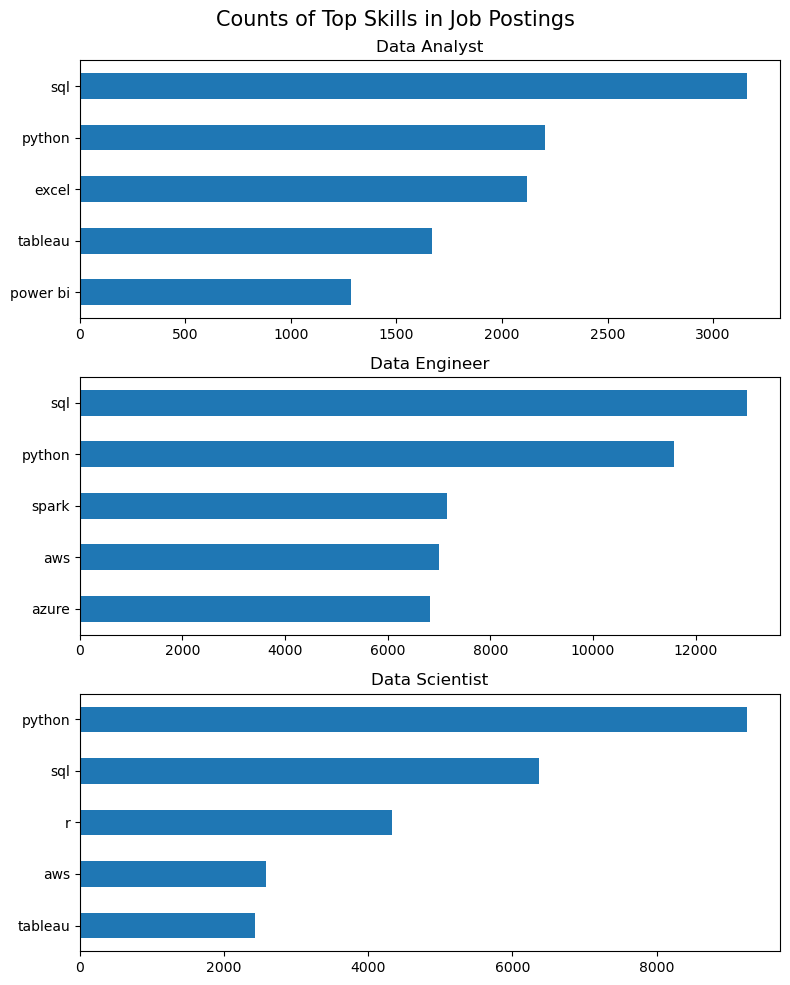

In [61]:
fig, ax = plt.subplots(len(job_titles), 1, figsize=(8, 10))

for i, job_title in enumerate(job_titles):

    df_plot = (
        df_skills_count[df_skills_count['job_title_short'] == job_title]
        .head(5)
    )

    df_plot.plot(
        kind='barh',
        x='job_skills',
        y='skill_count',
        ax=ax[i],
        title=job_title
    )

    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)

fig.suptitle('Counts of Top Skills in Job Postings', fontsize=15)

plt.tight_layout()
plt.show()

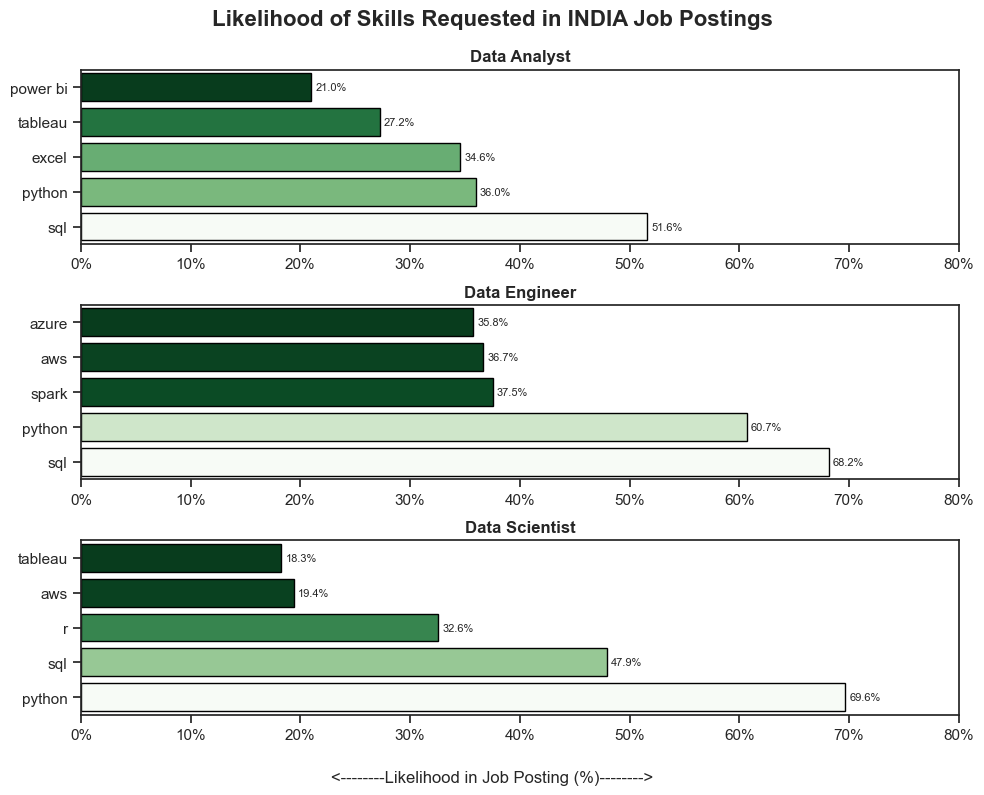

In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Style
sns.set_theme(style='ticks')

# Create subplots
fig, ax = plt.subplots(
    len(job_titles),
    1,
    figsize=(10, 8)
)

for i, job_title in enumerate(job_titles):

    # Filter top 5 skills for each role
    df_plot = (
        df_skills_perc[
            df_skills_perc['job_title_short'] == job_title
        ]
        .head(5)
    )

    # Plot
    sns.barplot(
        data=df_plot,
        x='skill_percent',
        y='job_skills',
        ax=ax[i],
        hue='skill_percent',
        palette='Greens_r',
        legend=False,
        edgecolor='black',
        linewidth=1
    )

    # Titles
    ax[i].set_title(
        job_title,
        fontsize=12,
        fontweight='bold'
    )

    # Highest value on top
    ax[i].invert_yaxis()

    # Consistent scale
    ax[i].set_xlim(0, 80)

    # Percentage formatting
    ax[i].xaxis.set_major_formatter(
        PercentFormatter()
    )

    # Remove repeated labels
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')

    # Add value labels
    for container in ax[i].containers:
        ax[i].bar_label(
            container,
            fmt='%.1f%%',
            padding=3,
            fontsize=8
        )

# Main title
fig.suptitle(
    'Likelihood of Skills Requested in INDIA Job Postings',
    fontsize=16,
    fontweight='bold'
)

# Shared x-label
fig.supxlabel(
    '<--------Likelihood in Job Posting (%)-------->',
    fontsize=12
)

# Better spacing
fig.tight_layout(h_pad=0.8)

plt.show()